# Figure 4: Three-Tier Performance Overview

**OCD-GMAE 62 Dataset — Three-Tier Analysis**

## Panels
- **Panel a**: Ablation Study (梯形图) - row 1, full width
- **Panel b**: Energy Range by Backend (12 cases) - row 2, col 1
- **Panel c**: Stability Quantification (Tier 2 稳定性) - row 2, col 2

## Layout
```
+-------------------+
|        (a) Wide   |
+---------+---------+
|  (b)    |  (c)    |
+---------+---------+
```


In [344]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Polygon
from matplotlib.colors import to_rgba


In [345]:
# ---- Define absolute paths (avoid working directory issues) ----
NOTEBOOK_DIR = Path.cwd()  # Assuming this notebook is run from the project root

# Data files (absolute paths)
ABLATION_CSV = (
    Path("../../results")
    / "basic_experiments" / "ocd62" / "summaries"
    / "ablation_4backend.csv"
)
REPRODUCIBILITY_CSV = (
    Path("../../results")
    / "advanced_experiments" / "reproducibility" / "ocd62_overlap12_rerun" / "summaries"
    / "reproducibility_n3.csv"
)
OCD62_PATTERN = str(
    Path("../../results")
    / "basic_experiments" / "ocd62" / "*" / "all_variants_summary.csv"
)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ABLATION_CSV:", ABLATION_CSV)
print("  exists:", ABLATION_CSV.exists())
print("REPRODUCIBILITY_CSV:", REPRODUCIBILITY_CSV)
print("  exists:", REPRODUCIBILITY_CSV.exists())
print("OCD62_PATTERN:", OCD62_PATTERN)


NOTEBOOK_DIR: c:\Users\15027\Desktop\github_work\AdsMind\research\paper_plots\figure4
ABLATION_CSV: ..\..\results\basic_experiments\ocd62\summaries\ablation_4backend.csv
  exists: True
REPRODUCIBILITY_CSV: ..\..\results\advanced_experiments\reproducibility\ocd62_overlap12_rerun\summaries\reproducibility_n3.csv
  exists: True
OCD62_PATTERN: ..\..\results\basic_experiments\ocd62\*\all_variants_summary.csv


In [346]:
# ---- Trapezoid Plot Configuration (for Panel d) ----
# ---- Configuration ----
BACKEND_ORDER = ["gemini", "gpt", "claude", "grok"]
BACKEND_LABEL = {
    "gemini": "Gemini 2.5 Pro",
    "gpt": "GPT-5.4",
    "claude": "Claude\nSonnet 4.6",
    "grok": "Grok-4",
}

BACKEND_LABEL_unwrap = {
    "gemini": "Gemini 2.5 Pro",
    "gpt": "GPT-5.4",
    "claude": "Claude Sonnet 4.6",
    "grok": "Grok-4",
}

BACKEND_COLOR = {
    "gemini": "#7EA6E0",
    "gpt": "#F08A7B",
    "claude": "#FFCC00",
    "grok": "#43B988",
}
VARIANT_ORDER = ["one_shot", "no_slip", "no_forbid", "no_termination"]
VARIANT_LABEL = {
    "one_shot": "1-Shot",
    "no_slip": "w/o Slip",
    "no_forbid": "w/o Forbid",
    "no_termination": "w/o Term",
}

# Paths (USE ABSOLUTE PATH to avoid working directory issues)

DATA_FILE = Path("../../results/basic_experiments/ocd62/summaries/ablation_4backend.csv")

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("DATA_FILE:", DATA_FILE)
print("File exists:", DATA_FILE.exists())

NOTEBOOK_DIR: c:\Users\15027\Desktop\github_work\AdsMind\research\paper_plots\figure4
DATA_FILE: ..\..\results\basic_experiments\ocd62\summaries\ablation_4backend.csv
File exists: True


In [347]:
def load_ocd62_data(csv_path_pattern: str) -> pd.DataFrame:
    """Load OCD-GMAE 62 ablation data from all_variants_summary.csv files.
    
    Args:
        csv_path_pattern: glob pattern like 
            "/Users/lixuecheng/Documents/ai4qc/AdsMind/research/results/basic_experiments/ocd62/*/all_variants_summary.csv"
    
    Returns:
        DataFrame with columns: case_id, backend_key, variant_key, delta_eV
    """
    import glob
    files = sorted(glob.glob(csv_path_pattern))
    
    all_dfs = []
    for f in files:
        df = pd.read_csv(f)
        all_dfs.append(df)
    
    df = pd.concat(all_dfs, ignore_index=True)
    
    # Compute delta_eV = best_energy - energy_full for each case+backend
    # Note: CSV has 'best_energy' (not 'best_energy_eV')
    # Note: CSV has 'backend_key' (not 'backend')
    full_df = df[df["variant"] == "full"][["case_id", "backend_key", "best_energy"]].copy()
    full_df = full_df.rename(columns={"best_energy": "energy_full"})
    df = df.merge(full_df, on=["case_id", "backend_key"], how="left")
    df["delta_eV"] = df["best_energy"] - df["energy_full"]
    
    # Rename variant column for consistency
    df = df.rename(columns={"variant": "variant_key"})
    
    return df

def plot_trapezoid_panel(ax, df, title=None):
    """Draw one panel in cmu20_llm_performance_v3 style."""
    rng = np.random.default_rng(2026)

    # Y-axis limits from all values
    all_vals = df["delta_eV"].dropna().to_numpy()
    if len(all_vals) == 0:
        all_vals = np.array([0.0])
    y_min = float(np.nanmin(all_vals))
    y_max = float(np.nanmax(all_vals))
    y_pad = 0.08 * max(1e-6, y_max - y_min)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    x_base = np.arange(1, len(VARIANT_ORDER) + 1)
    offset_span = 0.54
    offsets = np.linspace(-offset_span / 2.0, offset_span / 2.0, len(BACKEND_ORDER))
    box_half_width = 0.065
    neck_half_width = 0.6 * box_half_width

    for offset, bk in zip(offsets, BACKEND_ORDER):
        color = BACKEND_COLOR[bk]
        df_sub = df[df["backend_key"] == bk]
        values_by_var = [
            df_sub[df_sub["variant_key"] == v]["delta_eV"].dropna().to_numpy()
            for v in VARIANT_ORDER
        ]
        x_positions = x_base + offset

        # Min-max whiskers (no box)
        ax.boxplot(
            values_by_var,
            positions=x_positions,
            widths=2.0 * box_half_width,
            whis=(0, 100),
            patch_artist=True,
            showfliers=False,
            boxprops={"facecolor": "none", "edgecolor": "none", "linewidth": 0.0},
            whiskerprops={"color": color, "linewidth": 1.2},
            capprops={"color": color, "linewidth": 1.2},
            medianprops={"color": color, "linewidth": 0.0},
        )

        # Trapezoid IQR bodies + median line + mean diamond
        for pos, vals in zip(x_positions, values_by_var):
            if len(vals) == 0:
                continue
            q1 = float(np.nanpercentile(vals, 25))
            q3 = float(np.nanpercentile(vals, 75))
            median_val = float(np.nanmedian(vals))
            mean_val = float(np.nanmean(vals))

            # Lower trapezoid (Q1 -> median)
            lower = Polygon(
                [(pos - box_half_width, q1), (pos + box_half_width, q1),
                 (pos + neck_half_width, median_val), (pos - neck_half_width, median_val)],
                closed=True,
                facecolor=to_rgba(color, 0.22),
                edgecolor=color,
                linewidth=1.4,
                zorder=3.1,
            )
            # Upper trapezoid (median -> Q3)
            upper = Polygon(
                [(pos - neck_half_width, median_val), (pos + neck_half_width, median_val),
                 (pos + box_half_width, q3), (pos - box_half_width, q3)],
                closed=True,
                facecolor=to_rgba(color, 0.22),
                edgecolor=color,
                linewidth=1.4,
                zorder=3.1,
            )
            ax.add_patch(lower)
            ax.add_patch(upper)

            # Median line
            ax.hlines(
                median_val,
                pos - neck_half_width,
                pos + neck_half_width,
                color=color,
                linewidth=2.0,
                zorder=3.8,
            )

            # Mean diamond
            ax.scatter(
                pos, mean_val,
                marker="D",
                s=70,
                facecolor="white",
                edgecolor=color,
                linewidth=1.4,
                zorder=4,
            )

            # Individual points with jitter
            jitter = rng.uniform(-0.028, 0.028, size=len(vals))
            ax.scatter(
                np.full_like(vals, pos, dtype=float) + jitter,
                vals,
                s=28,
                color=color,
                edgecolors="white",
                linewidths=0.45,
                alpha=0.6,
                zorder=5,
            )

    # Reference lines
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.1, alpha=0.9, zorder=2)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)
    ax.axhline(-0.5, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)

    ax.set_xticks(list(x_base))
    ax.set_xticklabels([VARIANT_LABEL[v] for v in VARIANT_ORDER])
    # x-axis label colors (matching Panel B legend)
    colors_xaxis = ['#CF2526', '#85AF96', '#9BCAD5', '#C298C6']
    for tick, color in zip(ax.get_xticklabels(), colors_xaxis):
        tick.set_color(color)
    ax.set_xlim(0.5, len(VARIANT_ORDER) + 0.5)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.65, alpha=0.55)
    ax.grid(False, axis="x")
    ax.set_ylabel(r"ΔE = $\mathbf{E}_{\mathbf{variant}} - \mathbf{E}_{\mathbf{full}}$ (eV)", fontsize=14, fontweight="bold")
    ax.tick_params(axis="both", labelsize=14)
    if title:
        ax.set_title(title)
    return ax

print("plot_trapezoid_panel() defined.")


plot_trapezoid_panel() defined.


In [348]:
def load_tier1_tier2_data(csv_path: Path) -> dict:
    """Load Tier 1 (62 cases) & Tier 2 (24 cases) ablation data."""
    df = pd.read_csv(csv_path)
    
    # CSV already has 'backend_key' column, no need to rename
    # Just rename 'variant' to 'variant_key' for consistency
    df = df.rename(columns={"variant": "variant_key"})
    
    # Compute energy_full_eV for each case+backend
    full_df = df[df["variant_key"] == "full"][["case_id", "backend_key", "best_energy_eV"]].copy()
    full_df = full_df.rename(columns={"best_energy_eV": "energy_full_eV"})
    df = df.merge(full_df, on=["case_id", "backend_key"], how="left")
    df["delta_eV"] = df["best_energy_eV"] - df["energy_full_eV"]
    
    results = {}
    for variant in ["full", "one_shot"]:
        # Tier 1: all 62 cases
        df_t1 = df[(df["case_id"].isin(range(1, 63))) & (df["variant_key"] == variant)]
        success_t1 = df_t1["success"].mean() * 100
        delta_t1 = df_t1["delta_eV"].mean() if variant != "full" else 0.0
        
        # Tier 2: 24 cases (subset)
        df_t2 = df[(df["case_id"].isin(range(1, 25))) & (df["variant_key"] == variant)]
        success_t2 = df_t2["success"].mean() * 100
        delta_t2 = df_t2["delta_eV"].mean() if variant != "full" else 0.0
        
        results[f"tier1_{variant}"] = {"success_rate": success_t1, "mean_delta_e": delta_t1}
        results[f"tier2_{variant}"] = {"success_rate": success_t2, "mean_delta_e": delta_t2}
    
    return results

def load_tier3_data(csv_path: Path) -> dict:
    """Load Tier 2 (12 cases, N=3) reproducibility data."""
    df = pd.read_csv(csv_path)
    
    # Use existing std_eV column (already computed from e_run1, e_run2, e_run3)
    # Use backend_key (short name) to match BACKEND_ORDER
    sigma_df = df[df["variant"] == "full"][["case_id", "backend_key", "std_eV"]].copy()
    sigma_df = sigma_df.rename(columns={"std_eV": "sigma"})
    
    # Range values for panel b (all variants)
    range_df = df[["case_id", "backend_key", "variant", "range_eV"]].copy()
    
    # Mean sigma per backend (using backend_key short names)
    mean_sigma = sigma_df.groupby("backend_key")["sigma"].mean()
    
    # Tier 2 success rates for panel b (within 0.01 eV agreement)
    ok_classes = {"exact_match", "match"}
    skip_classes = {"outlier_excluded", "missing"}
    tier2_success_rates = {}
    for variant in ["full", "one_shot"]:
        df_v = df[df["variant"] == variant].copy()
        df_v = df_v[~df_v["agreement_class"].isin(skip_classes)]
        if df_v.empty:
            tier2_success_rates[variant] = np.nan
        else:
            tier2_success_rates[variant] = df_v["agreement_class"].isin(ok_classes).mean() * 100
    
    return {
        "sigma_df": sigma_df
        ,"range_df": range_df
        ,"mean_sigma": mean_sigma
        ,"tier2_success_rates": tier2_success_rates
    }


def draw_figure1(tier12_data, tier3_data, ocd62_data):
    """Draw Figure 1 with 3 panels (a, b, c).
    
    Layout: 2 rows × 2 columns
    - Row 1: Panel a (spans both columns)
    - Row 2: Panel b (col 0), Panel c (col 1)
    """
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1.0], width_ratios=[1.0, 1.0], hspace=0.28, wspace=0.25)
    
    ax_a = fig.add_subplot(gs[0, :])
    ax_b = fig.add_subplot(gs[1, 0])
    ax_c = fig.add_subplot(gs[1, 1])
    
    ax_a.spines["top"].set_visible(False)
    ax_a.spines["right"].set_visible(False)
    
    # ============================================================
    # Panel b: Energy range distribution (merged over variants, N=3)
    # ============================================================
    range_df = tier3_data["range_df"].copy()
    range_vals = range_df["range_eV"].dropna().to_numpy()
    if range_vals.size == 0:
        range_vals = np.array([1e-6])
    min_edge = max(float(np.nanmin(range_vals)) * 0.8, 1e-6)
    max_edge = float(np.nanmax(range_vals)) * 1.2
    if max_edge <= min_edge:
        max_edge = min_edge * 10.0
    bin_edges = np.array([1e-4, 0.001, 0.01, 0.1, 1.0, 10.0], dtype=np.float64)
    bin_centers = np.sqrt((bin_edges[:-1] + 1e-4) * bin_edges[1:])
    # bin_edges = np.linspace(0, 2, num=11)
    # bin_centers = (bin_edges[:-1]+ bin_edges[1:])/2.0
    
    log_left_edges = np.log10(bin_edges[:-1])
    log_right_edges = np.log10(bin_edges[1:])
    log_centers = np.log10(np.sqrt(bin_edges[:-1] * bin_edges[1:]))
    log_widths = log_right_edges - log_left_edges
    group_width = 0.75
    per_backend_width = log_widths * group_width / len(BACKEND_ORDER)

    for idx, bk in enumerate(BACKEND_ORDER):
        vals = range_df[range_df["backend_key"] == bk]["range_eV"].dropna().to_numpy()
        vals = np.maximum(vals, bin_edges[0])
        counts, _ = np.histogram(vals, bins=bin_edges)
        left_log = log_centers - (log_widths * group_width) / 2.0 + idx * per_backend_width
        left = 10 ** left_log
        width = (10 ** (left_log + per_backend_width)) - left
        ax_b.bar(
            left,
            counts,
            width=width,
            align="edge",
            color=BACKEND_COLOR[bk],
            alpha=0.75,
            edgecolor="white",
            linewidth=0.5,
            label=BACKEND_LABEL[bk],
        )
        
    ax_b.spines["top"].set_visible(False)
    ax_b.spines["right"].set_visible(False)
    
    ax_b.set_xscale("log")
    ax_b.set_xlim(left=1e-4)
    ax_b.set_xticks([1e-3, 1e-2, 1e-1, 1.0, 10.0])
    ax_b.set_xlabel("Tier 2 energy disagreement (eV)", fontsize=14, fontweight="bold")
    ax_b.set_ylabel("Count (cases)", fontsize=14, fontweight="bold")
    ax_b.tick_params(axis="both", labelsize=12)
    ax_b.grid(True, axis="both", linestyle="--", linewidth=0.6, alpha=0.5)
    ax_b.text(-0.11, 0.98, "b", transform=ax_b.transAxes, fontsize=20, fontweight="bold")
    
    # ============================================================
    # Panel c: Stability quantification for Tier 2 (mean with min/max)
    # ============================================================
    sigma_df = tier3_data["sigma_df"].copy()
    stats_df = (
        sigma_df.groupby("backend_key")["sigma"]
        .agg(["mean", "min", "max"])
        .reindex(BACKEND_ORDER)
    )
    means = stats_df["mean"].to_numpy()
    yerr = np.vstack([means - stats_df["min"].to_numpy(), stats_df["max"].to_numpy() - means])
    x_pos = np.arange(len(BACKEND_ORDER))
    
    ax_c.bar(
        x_pos,
        means,
        color=[BACKEND_COLOR[bk] for bk in BACKEND_ORDER],
        width=0.6,
        edgecolor="black",
        linewidth=1.0,
        label="Mean σ",
    )
    ax_c.errorbar(
        x_pos,
        means,
        yerr=yerr,
        fmt="o",
        color="black",
        capsize=6,
        elinewidth=1.2,
        markersize=4,
        zorder=5,
        label="Min/Max",
    )
    
    # Reference line at 0.02 eV (stability threshold)
    #ax_c.axhline(0.02, color="red", linestyle="--", linewidth=1.2, alpha=0.7,                 label="0.02 eV threshold")
    ax_c.spines["top"].set_visible(False)
    ax_c.spines["right"].set_visible(False)
    
    ax_c.set_xticks(x_pos)
    ax_c.set_xticklabels([BACKEND_LABEL[bk] for bk in BACKEND_ORDER], fontsize=12, va = "center")
    ax_c.tick_params(axis="x", pad=12)
    ax_c.set_ylabel("σ (eV)", fontsize=14, fontweight="bold")
    ax_c.tick_params(axis="y", labelsize=12)
    ax_c.set_ylim(bottom=0)
    ax_c.legend(loc="upper right", fontsize=10, frameon=False)
    ax_c.text(-0.13, 0.98, "c", transform=ax_c.transAxes, fontsize=20, fontweight="bold")

    # Annotation: N=3 (Run 4-5 pending)
    ax_c.text(0.02, 0.95, "N=3 (Run 4-5 pending)", transform=ax_c.transAxes,
              fontsize=10, style="italic", color="gray",
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))
    for tick, color in zip(ax_c.get_xticklabels(), BACKEND_COLOR.values()):
        tick.set_color(color)
    ax_c.set_xlabel("Tier 2 energy standard deviation (eV)", fontsize=14, fontweight="bold")

    
    # Panel a: OCD-GMAE 62 Ablation (trapezoid plot)
    # ============================================================
    plot_trapezoid_panel(ax_a, ocd62_data)
    ax_a.text(-0.05, 0.98, "a", transform=ax_a.transAxes, fontsize=20, fontweight="bold")
    
    # Legends for Panel a
    llm_handles = [
        mpatches.Patch(facecolor=BACKEND_COLOR[bk], edgecolor="none", label=BACKEND_LABEL_unwrap[bk])
        for bk in BACKEND_ORDER
    ]
    legend_llm = ax_a.legend(
        handles=llm_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.1),
        ncol=len(BACKEND_ORDER),
        frameon=False,
        handlelength=1.0,
        handleheight=1.0,
        columnspacing=1.4,
        fontsize=16,
    )
    ax_a.add_artist(legend_llm)
    
    style_handles = [
        mpatches.Patch(facecolor=to_rgba("#666666", 0.22), edgecolor="black", linewidth=1.4, label="IQR box"),
        Line2D([0], [0], color="black", linewidth=2.0, label="Median"),
        Line2D([0], [0], marker="D", linestyle="None", markersize=7,
               markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.2, label="Mean"),
        Line2D([0], [0], marker="o", linestyle="None", markersize=6,
               markerfacecolor="#666666", markeredgecolor="white", markeredgewidth=0.7,
               alpha=0.6, label="Individual case"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.1, label="Ground truth (Error = 0 eV)"),
        Line2D([0], [0], color="black", linestyle=":", linewidth=1.1, label="Tolerance band (Error = ±0.05 eV)"),
    ]
    ax_a.legend(handles=style_handles, bbox_to_anchor=(1.0, 0.95),
                loc="upper right", fontsize=10, frameon=False)
    ax_a.set_xlabel("Tier 1 Ablation setting", fontsize=14, fontweight="bold")
    
    # ============================================================
    # Save
    # ============================================================
    output_path = NOTEBOOK_DIR / "figure4_three_tier_overview.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved to: {output_path}")
    
    return fig

## Single Cell: Generate Figure 1 (Three Panels)

All three panels in one cell for easy regeneration.

Loaded 1240 rows from ablation_4backend.csv
Tier 1 (62 cases): 62 unique cases
Loaded 240 rows from reproducibility_n3.csv
Tier 2 (12 cases, N=3): 12 unique cases

Mean σ across 12 cases (Full variant, N=3):
  claude: 0.0583 eV
  gemini: 0.0456 eV
  gpt: 0.1964 eV
  grok: 0.1093 eV

Tier 2 success rates (agreement within 0.01 eV):
  full: 55.3%
  one_shot: 56.2%
tier1_full          : 98.8%, ΔE = 0.0000 eV
tier1_one_shot      : 89.5%, ΔE = 0.3285 eV
Loaded OCD62 data: 1240 rows
Saved to: c:\Users\15027\Desktop\github_work\AdsMind\research\paper_plots\figure4\figure4_three_tier_overview.png


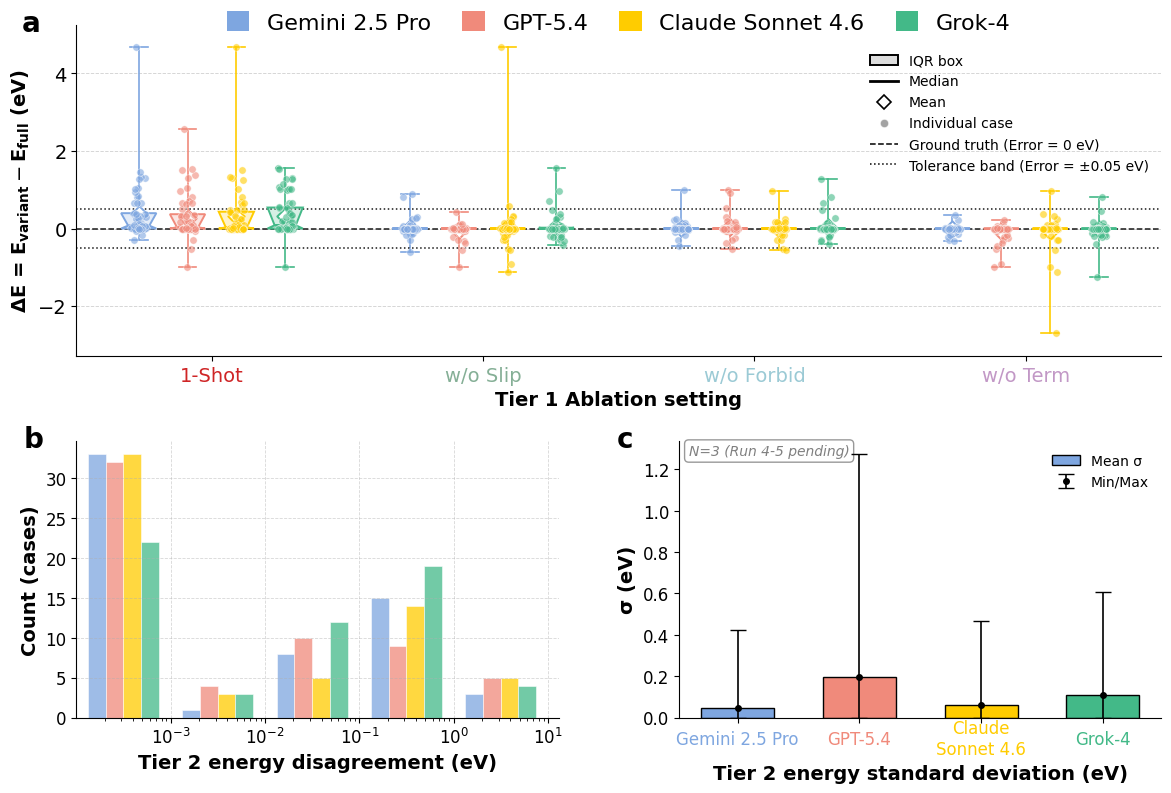

In [349]:
# =====================================================================
# Loading Tier 1 data (62 cases)...
# =====================================================================
tier12_data = load_tier1_tier2_data(ABLATION_CSV)
print(f"Loaded {pd.read_csv(ABLATION_CSV).shape[0]} rows from {ABLATION_CSV.name}")
print(f"Tier 1 (62 cases): {len(pd.read_csv(ABLATION_CSV)['case_id'].unique())} unique cases")

# =====================================================================
# Loading Tier 2 data (12 cases, N=3)...
# =====================================================================
tier3_data = load_tier3_data(REPRODUCIBILITY_CSV)
print(f"Loaded {pd.read_csv(REPRODUCIBILITY_CSV).shape[0]} rows from {REPRODUCIBILITY_CSV.name}")
print(f"Tier 2 (12 cases, N=3): {len(pd.read_csv(REPRODUCIBILITY_CSV)['case_id'].unique())} unique cases")

print("\nMean σ across 12 cases (Full variant, N=3):")
for bk in tier3_data["mean_sigma"].index:
    print(f"  {bk}: {tier3_data['mean_sigma'][bk]:.4f} eV")

print("\nTier 2 success rates (agreement within 0.01 eV):")
for variant, rate in tier3_data["tier2_success_rates"].items():
    if np.isnan(rate):
        print(f"  {variant}: n/a")
    else:
        print(f"  {variant}: {rate:.1f}%")

# =====================================================================
# Summary of Tier 1:
# =====================================================================
for key in ["tier1_full", "tier1_one_shot"]:
    d = tier12_data[key]
    print(f"{key:20s}: {d['success_rate']:.1f}%, ΔE = {d['mean_delta_e']:.4f} eV")

# =====================================================================
# Loading OCD62 data for Panel d...
# =====================================================================
ocd62_data = load_ocd62_data(OCD62_PATTERN)
print(f"Loaded OCD62 data: {ocd62_data.shape[0]} rows")

# =====================================================================
# Generate Figure 1
# =====================================================================
fig = draw_figure1(tier12_data, tier3_data, ocd62_data)
